# TracIn - CIFAR-10 Efficient Implementation

This notebook implements the TracIn algorithm for the CIFAR-10 dataset as described in the paper _Estimating Training Data Influence by Tracing Gradient Descent_.

It includes **critical performance optimizations** to ensure it runs efficiently:
1. **Inverted Checkpoint Loops:** Model weights are loaded only *once* per checkpoint, completely eliminating the bottleneck of loading state dicts repeatedly.
2. **Self-Influence Optimization:** Computes the $L_2$ norm squared instead of computing identical gradients twice.
3. **Complete Final Layer:** Extracts both weights and bias gradients for the final ResNet layer to be mathematically precise.

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)

Using device: cuda


## 1. Load the CIFAR-10 Data

### Evaluation Approach: CIFAR-10
**Reference: Paper Section 4.1 & 4.2**

We evaluate `TracIn` on ResNet models trained on CIFAR-10. We compute self-influence, i.e., the influence of a training point on its own loss. By sorting training examples by decreasing self-influence, an effective influence computation method would tend to rank mislabelled examples in the beginning of the ranking.
In our implementation, we use a ResNet-18 model to demonstrate the process faster. We also compute gradients only with respect to the last layer, concatenating weights and biases.


In [4]:
# Standard CIFAR-10 normalization and augmentation for training
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Test normalization (no augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

train_nonaug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_test
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=2, pin_memory=True
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## 2. Model Definition & Training (with Checkpoints)
The paper uses ResNet-56 trained for 270 epochs. For demonstration purposes, we will use `ResNet-18` and train for 15 epochs, saving checkpoints at epochs 5, 10, and 15. This allows the notebook to run in a reasonable amount of time.

### Practical Heuristic via Checkpoints
**Reference: Paper Section 3.3**

Tracing parameters at every iteration is impractical. `TracInCP` employs a heuristic: storing checkpoints during training at regular intervals. It sums the gradient dot products evaluated at these checkpoints, weighted by the learning rate.
$$TracInCP(z, z') = \sum_{i=1}^k \eta_i \nabla\ell(w_{t_i}, z) \cdot \nabla\ell(w_{t_i}, z')$$
For influence functions, it is prohibitively expensive to compute the Hessian for the whole model, so we work with parameters in the last layer, essentially considering the layers below the last as frozen.


In [3]:
# Use ResNet18 and modify the final fully connected layer for 10 classes
model = models.resnet18(num_classes=10).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

checkpoints = []
checkpoint_epochs = [5, 10, 15]

# Note: Reduce the range if you want this to run faster, or load a pre-trained model
for epoch in range(15):
    model.train()
    running_loss = 0.0
    for data, target in tqdm(train_loader, desc=f'Epoch {epoch+1}/15', leave=False):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")
    
    if epoch + 1 in checkpoint_epochs:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
            'learning_rate': 0.01
        }
        checkpoints.append(checkpoint)
        torch.save(model.state_dict(), f'cifar10_checkpoint_epoch_{epoch+1}.pt')
        print(f'>>> Saved checkpoint at epoch {epoch+1} <<<')

Epoch 1/15:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 1 Loss: 1.7214


Epoch 2/15:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 2 Loss: 1.3827


Epoch 3/15:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 13 Loss: 0.7022


Epoch 14/15:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 14 Loss: 0.6781


Epoch 15/15:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 15 Loss: 0.6574
>>> Saved checkpoint at epoch 15 <<<


## 3. Efficient TracIn Implementation

### Understanding TracIn: Tracing Gradient Descent
**Reference: Paper Section 3.1 & 3.2**

TracIn is a method introduced to estimate the influence of a specific training example on a model's prediction for a test example. It decomposes the difference between the loss of the test point at the end of training versus at the beginning of training along the path taken by the training process.

**1. Idealized Influence (`TracIn_Ideal`)**
The idealized influence of a training example $z$ on a test example $z'$ is defined as the total reduction in the loss on the test example $z'$ induced by the training process whenever the training example $z$ is utilized.

**2. First-Order Approximation (`TracIn`)**
To make the method practical, the change in loss is approximated using a first-order Taylor expansion. The change in loss at a single step $t$ is approximately the dot product of the test loss gradient and the parameter update vector:
$$TracIn(z, z') = \sum_{t: z_t=z} \eta_t \nabla\ell(w_t, z') \cdot \nabla\ell(w_t, z)$$


In [ ]:
def compute_last_layer_gradient(model, example, label, criterion, device):
    model.zero_grad()
    example = example.unsqueeze(0).to(device)
    label = label.to(device)
    output = model(example)
    loss = criterion(output, label)
    loss.backward()
    
    # ResNet18 last layer is named 'fc'
    # We safely concatenate weights and bias to be completely precise
    grad_weight = model.fc.weight.grad.view(-1)
    if model.fc.bias is not None:
        grad_bias = model.fc.bias.grad.view(-1)
        grad = torch.cat([grad_weight, grad_bias])
    else:
        grad = grad_weight
        
    return grad.detach().cpu()

In [6]:
def compute_all_self_influences(train_dataset, checkpoints, criterion, device, max_examples=5000):
    """
    Optimized self-influence calculation.
    Instead of loading checkpoints for each example, we invert the loops.
    Instead of computing identical gradients twice, we use the L2 norm squared.
    """
    num_examples = min(max_examples, len(train_dataset))
    self_influences = np.zeros(num_examples)
    
    # 1. Loop over checkpoints (outer loop)
    for checkpoint in checkpoints:
        model = models.resnet18(num_classes=10).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        lr = checkpoint['learning_rate']
        
        # 2. Loop over training dataset (inner loop)
        for idx in tqdm(range(num_examples), desc=f"Self-influences (Epoch {checkpoint['epoch']})"):
            example, label_int = train_dataset[idx]
            label = torch.tensor([label_int])
            
            grad_train = compute_last_layer_gradient(model, example, label, criterion, device)
            
            # For self-influence, z = z', so dot product is just sum of squares (L2 norm squared)
            dot_product = torch.sum(grad_train ** 2).item()
            self_influences[idx] += lr * dot_product
            
    return self_influences, list(range(num_examples))

In [7]:
from torch.func import functional_call, vmap, grad

def compute_all_self_influences_functorch(train_dataset, checkpoints, criterion, device, 
                                           max_examples=5000, batch_size=256):
    """
    Ultra-fast version using functorch for vectorized per-sample gradients.
    """
    num_examples = min(max_examples, len(train_dataset))
    self_influences = np.zeros(num_examples)
    
    subset_indices = list(range(num_examples))
    subset_dataset = torch.utils.data.Subset(train_dataset, subset_indices)
    dataloader = torch.utils.data.DataLoader(
        subset_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )
    
    for checkpoint in checkpoints:
        model = models.resnet18(num_classes=10).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        lr = checkpoint['learning_rate']
        
        # Extract only last layer parameters
        params = {k: v.detach() for k, v in model.fc.named_parameters()}
        buffers = {}
        
        def compute_loss_fc_only(params, buffers, input_features, target):
            """Compute loss using only fc layer"""
            logits = torch.nn.functional.linear(input_features, params['weight'], params.get('bias'))
            return criterion(logits.unsqueeze(0), target.unsqueeze(0))
        
        ft_compute_grad = grad(compute_loss_fc_only)
        ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0, 0))
        
        current_idx = 0
        for batch_examples, batch_labels in tqdm(dataloader, desc=f"Epoch {checkpoint['epoch']}"):
            batch_examples = batch_examples.to(device)
            batch_labels = batch_labels.to(device)
            
            # Get features from all layers except last
            with torch.no_grad():
                features = model.avgpool(model.layer4(model.layer3(model.layer2(model.layer1(
                    model.maxpool(model.relu(model.bn1(model.conv1(batch_examples)))))))))
                features = torch.flatten(features, 1)
            
            # Compute per-sample gradients for last layer
            per_sample_grads = ft_compute_sample_grad(params, buffers, features, batch_labels)
            
            # Compute self-influence
            for i in range(len(batch_labels)):
                grad_vec = torch.cat([per_sample_grads['weight'][i].flatten(), 
                                     per_sample_grads['bias'][i].flatten() if 'bias' in per_sample_grads else torch.tensor([])])
                self_influences[current_idx] += lr * torch.sum(grad_vec ** 2).item()
                current_idx += 1
        
        print(f"Completed checkpoint epoch {checkpoint['epoch']}")
    
    return self_influences, list(range(num_examples))

In [9]:
def load_checkpoints(checkpoint_epochs=[5, 10, 15], learning_rates=None):
    """
    Load saved model checkpoints from disk.
    
    Parameters:
    -----------
    checkpoint_epochs : list
        List of epoch numbers where checkpoints were saved
    learning_rates : list or float, optional
        Learning rates at each checkpoint. If None, uses 0.01 for all.
        If float, uses that value for all checkpoints.
        If list, must match length of checkpoint_epochs.
    
    Returns:
    --------
    checkpoints : list of dict
        List of checkpoint dictionaries with keys:
        - 'epoch': epoch number
        - 'model_state_dict': model weights
        - 'learning_rate': learning rate at that checkpoint
    """
    checkpoints = []
    
    # Handle learning_rates parameter
    if learning_rates is None:
        learning_rates = [0.01] * len(checkpoint_epochs)
    elif isinstance(learning_rates, (int, float)):
        learning_rates = [learning_rates] * len(checkpoint_epochs)
    elif len(learning_rates) != len(checkpoint_epochs):
        raise ValueError("learning_rates must match length of checkpoint_epochs")
    
    for epoch, lr in zip(checkpoint_epochs, learning_rates):
        checkpoint_path = f'cifar10_checkpoint_epoch_{epoch}.pt'
        
        try:
            state_dict = torch.load(checkpoint_path, map_location='cpu')
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': state_dict,
                'learning_rate': lr
            }
            checkpoints.append(checkpoint)
            print(f"✓ Loaded checkpoint from epoch {epoch}")
            
        except FileNotFoundError:
            print(f"✗ Warning: Checkpoint file not found: {checkpoint_path}")
        except Exception as e:
            print(f"✗ Error loading checkpoint from epoch {epoch}: {e}")
    
    if not checkpoints:
        raise RuntimeError("No checkpoints were loaded! Check your file paths.")
    
    print(f"\nSuccessfully loaded {len(checkpoints)} checkpoints")
    return checkpoints

checkpoints = load_checkpoints(checkpoint_epochs=[5, 10, 15])

✓ Loaded checkpoint from epoch 5
✓ Loaded checkpoint from epoch 10
✓ Loaded checkpoint from epoch 15

Successfully loaded 3 checkpoints


In [12]:
# Note: We limit to 5000 examples for demonstration speed. Increase max_examples for a full run.
self_influences, indices = compute_all_self_influences_functorch(
    train_nonaug, checkpoints, criterion, device, max_examples=5000
)

sorted_idx = np.argsort(self_influences)[::-1]

print("Top 10 high self-influence examples:")
for i in range(10):
    idx = sorted_idx[i]
    label_name = classes[train_dataset[idx][1]]
    print(f"Example {idx}: influence={self_influences[idx]:.4f}, label={label_name}")

Epoch 5:   0%|          | 0/20 [00:00<?, ?it/s]

Completed checkpoint epoch 5


Epoch 10:   0%|          | 0/20 [00:00<?, ?it/s]

Completed checkpoint epoch 10


Epoch 15:   0%|          | 0/20 [00:00<?, ?it/s]

Completed checkpoint epoch 15
Top 10 high self-influence examples:
Example 1782: influence=127.8102, label=ship
Example 1533: influence=114.4212, label=bird
Example 448: influence=100.0529, label=plane
Example 938: influence=84.9715, label=plane
Example 1413: influence=74.2812, label=car
Example 1797: influence=68.2189, label=ship
Example 1705: influence=63.1106, label=bird
Example 459: influence=62.0813, label=ship
Example 958: influence=61.6753, label=ship
Example 3972: influence=61.6158, label=ship


### Proponents and Opponents
**Reference: Paper Remark 3.2**

*   **Proponents**: Training examples that have a *positive* value of influence score, because they serve to reduce loss.
*   **Opponents**: Training examples that have a *negative* value of influence score, because they increase loss.


In [13]:
def find_proponents_opponents(test_example, test_label, train_dataset, 
                              checkpoints, criterion, device, top_k=5, max_train_examples=5000):
    """
    Optimized proponents/opponents calculation.
    Inverts the loop to prevent reloading the model for every training example.
    """
    num_examples = min(max_train_examples, len(train_dataset))
    scores = np.zeros(num_examples)
    
    # 1. Loop over checkpoints
    for checkpoint in checkpoints:
        model = models.resnet18(num_classes=10).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        lr = checkpoint['learning_rate']
        
        # 2. Compute test gradient ONCE per checkpoint
        grad_test = compute_last_layer_gradient(model, test_example, test_label, criterion, device)
        
        # 3. Loop over training dataset
        for idx in tqdm(range(num_examples), desc=f"Tracing Train Data (Epoch {checkpoint['epoch']})"):
            train_ex, train_label_int = train_dataset[idx]
            train_label = torch.tensor([train_label_int])
            
            grad_train = compute_last_layer_gradient(model, train_ex, train_label, criterion, device)
            dot_product = torch.dot(grad_train, grad_test).item()
            
            scores[idx] += lr * dot_product
            
    indexed_scores = [(scores[idx], idx) for idx in range(num_examples)]
    indexed_scores.sort(reverse=True)
    return indexed_scores[:top_k], indexed_scores[-top_k:]

In [14]:
# Pick a test example to analyze
test_idx = 42 # Arbitrary example
test_example, test_label_int = test_dataset[test_idx]
test_label = torch.tensor([test_label_int])

print(f"Analyzing Test Example {test_idx} (True Label: {classes[test_label_int]})")

proponents, opponents = find_proponents_opponents(
    test_example, test_label, train_nonaug, checkpoints, criterion, device, 
    top_k=5, max_train_examples=5000
)

print("\nProponents (helpful):", [(idx, f"{score:.4f}") for score, idx in proponents])
print("Opponents (harmful):", [(idx, f"{score:.4f}") for score, idx in opponents])

Analyzing Test Example 42 (True Label: dog)


Tracing Train Data (Epoch 5):   0%|          | 0/5000 [00:00<?, ?it/s]

Tracing Train Data (Epoch 10):   0%|          | 0/5000 [00:00<?, ?it/s]

Tracing Train Data (Epoch 15):   0%|          | 0/5000 [00:00<?, ?it/s]


Proponents (helpful): [(729, '6.8651'), (4019, '6.0608'), (3156, '5.9397'), (107, '5.8746'), (3132, '5.7666')]
Opponents (harmful): [(3340, '-5.0662'), (4268, '-5.0900'), (1696, '-5.2119'), (3782, '-5.5018'), (809, '-6.0715')]


## 4. Visualization

In [15]:
transform_viz = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

viz_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_viz
)

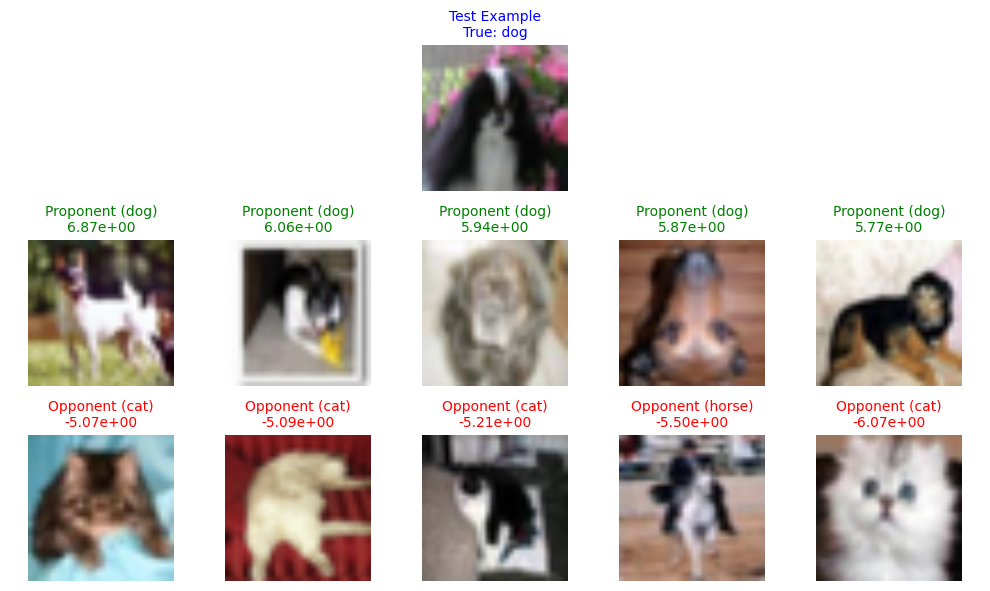

In [16]:
def imshow_unnormalized(img, ax, title, color):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img, interpolation='bilinear') #
    ax.set_title(title, color=color, fontsize=10)
    ax.axis('off')

def visualize_influences_cifar(test_example, test_label_int, proponents, opponents, train_dataset):
    fig, axes = plt.subplots(3, 5, figsize=(10, 6))
    
    # Display Test Image
    test_label_name = classes[test_label_int]
    imshow_unnormalized(test_example, axes[0, 2], f'Test Example\nTrue: {test_label_name}', 'blue')
    
    # Hide empty subplots in top row
    for i in [0, 1, 3, 4]: axes[0, i].axis('off')
    
    # Display Proponents
    for i, (score, idx) in enumerate(proponents):
        img, label_int = train_dataset[idx]
        label_name = classes[label_int]
        imshow_unnormalized(img, axes[1, i], f'Proponent ({label_name})\n{score:.2e}', 'green')
    
    # Display Opponents
    for i, (score, idx) in enumerate(opponents):
        img, label_int = train_dataset[idx]
        label_name = classes[label_int]
        imshow_unnormalized(img, axes[2, i], f'Opponent ({label_name})\n{score:.2e}', 'red')
    
    plt.tight_layout()
    plt.savefig('cifar10_tracin_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_influences_cifar(test_example, test_label_int, proponents, opponents, viz_train_dataset)